# Debugging the LR heuristic on wine quality

This notebook traces `lr_heuristic` on the `wine_quality / mlp` bundle. The target label below is the AI prediction stored in `datasets/none.csv`, matching the policy evaluation setup.

The main questions are: what probability does the heuristic assign to the target, what terms push it in the wrong direction, and do sequential belief updates help?

In [21]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'datasets').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.parameter_effect_sweep import (
    load_bundles,
    prime_lr_calculation_memory,
    prime_lr_heuristic_memory,
)
from src.cognitive import drift_diffusion_decision, lr_evidence
from src.heuristic_lr_model import lr_heuristic, refresh_lr_heuristic_in_memory
from src.lr_memory import lr_calculation

SEED = 17
rng = np.random.default_rng(SEED)
random.seed(SEED)
params = {
    'memory_recall_threshold': -3.0,
    'memory_recall_noise': 0.5,
    'decision_boundary': 1.0,
    'decision_noise': 0.3,
    'retrieval_candidate_count': 3,
    'simulation_sample_count': 256,
}

bundle = load_bundles(ROOT / 'datasets', apps=['wine_quality'])[0]
feature_names = bundle.loader.get_feature_names(bundle.app_id)
print(f'Dataset: {bundle.app_id} / {bundle.model_name}; instances: {len(bundle.instance_ids)}')
print(f'LR explanation fidelity: {bundle.lr_exp.fidelity:.3f}')

Dataset: wine_quality / mlp; instances: 400
LR explanation fidelity: 0.975


## 1. Explanation coefficients vs initial heuristic beliefs

`LogisticRegressionInterpreter` stores raw-input LR coefficients. The heuristic does not retain their magnitude initially: `add_lr_heuristic_to_memory` initializes each coefficient mean to its sign (`-1`, `0`, or `1`) and evaluates normalized feature values.

In [22]:
coefficient_rows = []
for key, raw_coef in bundle.lr_exp.coefficients.items():
    idx = int(key.split('=')[0][1:])
    coefficient_rows.append({
        'feature': feature_names.get(f'a{idx}', key),
        'key': key,
        'raw_lr_coefficient': raw_coef,
        'heuristic_initial_mu': float(np.sign(raw_coef)),
        'raw_bounds': bundle.bounds.get(f'a{idx}'),
    })
coef_df = pd.DataFrame(coefficient_rows)
display(pd.DataFrame([{'raw_lr_intercept': bundle.lr_exp.intercept, 'heuristic_initial_intercept_mu': 0.0}]))
display(coef_df.round(4))

,raw_lr_intercept,heuristic_initial_intercept_mu
0,-249.829222,0.0


,feature,key,raw_lr_coefficient,heuristic_initial_mu,raw_bounds
0,Alcohol,a0,41.6822,1.0,"(9.0, 12.9)"
1,Sulphates,a1,111.3661,1.0,"(0.44, 1.13)"
2,SO2,a2,-0.3395,-1.0,"(9.0, 135.0)"
3,Vinegar Taint,a3,-160.5113,-1.0,"(0.2296, 0.96)"
4,pH,a4,-50.8507,-1.0,"(3.0, 3.66)"
5,Chlorides,a5,-221.8242,-1.0,"(0.047, 0.226)"


## 2. Sampled probabilities with fresh memory

Each row below primes a new heuristic memory, as in a fresh episode before it has learned from prior examples. `P(target)` is expected accuracy: the probability assigned to the stored target label. The LR calculation column provides a reference strategy on the same instances. Instance sampling is seeded; probabilities can vary slightly between runs because `lr_heuristic` simulates decisions with an internal RNG.

In [23]:
sample_ids = rng.choice(np.asarray(bundle.instance_ids), size=12, replace=False).astype(int).tolist()
raw_xs, ys = bundle.loader.load_instances(sample_ids, normalize=False)
norm_xs, _ = bundle.loader.load_instances(sample_ids, normalize=True)

def heuristic_prediction(x, y, memory=None, *, simulation_sample_count=None, prediction_rng=None):
    memory = memory or prime_lr_heuristic_memory(bundle, params)
    probs, seconds, info = lr_heuristic(
        np.asarray(x, dtype=float), memory, bundle.lr_exp,
        simulation_sample_count=simulation_sample_count or params['simulation_sample_count'],
        retrieval_candidate_count=params['retrieval_candidate_count'],
        decision_boundary=params['decision_boundary'],
        decision_noise=params['decision_noise'],
        rng=prediction_rng,
    )
    return probs, seconds, info

sample_rows = []
for instance_id, raw_x, norm_x, y in zip(sample_ids, raw_xs, norm_xs, ys):
    y = int(y)
    h_probs, h_time, _ = heuristic_prediction(norm_x, y)
    calc_probs, calc_time, _ = lr_calculation(
        np.asarray(raw_x, dtype=float), prime_lr_calculation_memory(bundle, params), bundle.lr_exp,
        explanation_access_mode='read', decision_boundary=params['decision_boundary'],
        decision_noise=params['decision_noise'], simulation_sample_count=params['simulation_sample_count'],
        retrieval_candidate_count=params['retrieval_candidate_count'],
    )
    sample_rows.append({
        'instance_id': instance_id,
        'target': y,
        'heuristic_p1': h_probs[1],
        'heuristic_P(target)': h_probs[y],
        'heuristic_prediction': int(np.argmax(h_probs)),
        'lr_calc_P(target)': calc_probs[y],
        'heuristic_time': h_time,
    })

sample_df = pd.DataFrame(sample_rows).sort_values('heuristic_P(target)')
display(sample_df.round(3))
display(pd.DataFrame({
    'measure': ['Heuristic mean P(target)', 'LR calculation mean P(target)'],
    'value': [sample_df['heuristic_P(target)'].mean(), sample_df['lr_calc_P(target)'].mean()],
}).round(3))

,instance_id,target,heuristic_p1,heuristic_P(target),heuristic_prediction,lr_calc_P(target),heuristic_time
7,288,1,0.457,0.457,0,0.938,12.759
5,145,1,0.478,0.478,0,0.948,13.486
10,179,1,0.565,0.565,1,0.935,12.948
9,300,0,0.427,0.573,0,0.617,12.533
1,63,1,0.600,0.600,1,0.878,12.354
0,329,0,0.361,0.639,0,0.739,12.768
4,85,1,0.657,0.657,1,0.955,12.631
2,154,1,0.660,0.660,1,0.814,12.070
3,41,0,0.238,0.762,0,0.929,12.020
8,219,0,0.228,0.772,0,0.909,12.251


,measure,value
0,Heuristic mean P(target),0.650
1,LR calculation mean P(target),0.883


## 3. Find predictions near or below 50%

This scans every wine-quality instance with fresh heuristic memory. `P(target)` is the probability assigned to the stored AI prediction. A case is retained when `P(target) <= 0.50` or when it lies within `BORDERLINE_TOLERANCE` of 0.50. The per-instance random seed makes the scan reproducible.

In [ ]:
BORDERLINE_TOLERANCE = 0.03
SCAN_SIMULATION_SAMPLES = params['simulation_sample_count']
CASES_PER_GROUP = 3

all_ids = np.asarray(bundle.instance_ids, dtype=int)
all_raw_x, all_y = bundle.loader.load_instances(all_ids.tolist(), normalize=False)
all_norm_x, _ = bundle.loader.load_instances(all_ids.tolist(), normalize=True)

scan_rows = []
for instance_id, raw_x, norm_x, y in zip(all_ids, all_raw_x, all_norm_x, all_y):
    y = int(y)
    probs, seconds, _ = heuristic_prediction(
        norm_x,
        y,
        simulation_sample_count=SCAN_SIMULATION_SAMPLES,
        prediction_rng=np.random.default_rng(SEED + int(instance_id)),
    )
    p_target = float(probs[y])
    scan_rows.append({
        'instance_id': int(instance_id),
        'target': y,
        'heuristic_prediction': int(np.argmax(probs)),
        'heuristic_p0': float(probs[0]),
        'heuristic_p1': float(probs[1]),
        'heuristic_P(target)': p_target,
        'distance_to_50': abs(p_target - 0.5),
        'at_or_below_50': p_target <= 0.5,
        'time': float(seconds),
    })

scan_df = pd.DataFrame(scan_rows).sort_values('heuristic_P(target)').reset_index(drop=True)
candidate_df = scan_df[
    scan_df['at_or_below_50'] | (scan_df['distance_to_50'] <= BORDERLINE_TOLERANCE)
].copy()

lowest_cases = scan_df.nsmallest(CASES_PER_GROUP, 'heuristic_P(target)')
closest_cases = scan_df.nsmallest(CASES_PER_GROUP, 'distance_to_50')
selected_cases = (
    pd.concat([lowest_cases, closest_cases], ignore_index=True)
    .drop_duplicates('instance_id')
    .reset_index(drop=True)
)

print(f"At or below 50%: {int(scan_df['at_or_below_50'].sum())} / {len(scan_df)}")
print(f"Within +/-{BORDERLINE_TOLERANCE:.2f} of 50%: {int((scan_df['distance_to_50'] <= BORDERLINE_TOLERANCE).sum())}")
display(candidate_df.head(30).round(4))
print('Cases selected for plots and calculations:')
display(selected_cases.round(4))

### Attribute values relative to their bounds

Each horizontal line is the raw metadata or empirical range for one attribute. The marker is the selected instance's raw value, converted to a 0-to-1 position within that range. The annotation preserves the original value and bounds.

In [ ]:
raw_bounds = bundle.loader.get_bounds_for_app(bundle.app_id, normalized=False)

def plot_instance_relative_to_bounds(instance_id, ax):
    raw_values, _ = bundle.loader.load_instances([int(instance_id)], normalize=False)
    raw_values = np.asarray(raw_values[0], dtype=float)
    case = scan_df.loc[scan_df['instance_id'] == int(instance_id)].iloc[0]

    rows = []
    for idx, value in enumerate(raw_values):
        key = f'a{idx}'
        if key not in raw_bounds:
            continue
        low, high = raw_bounds[key]
        span = high - low
        relative = (value - low) / span if span > 0 else 0.5
        rows.append((feature_names.get(key, key), value, low, high, relative))

    labels = [row[0] for row in rows]
    positions = np.asarray([row[4] for row in rows], dtype=float)
    y_pos = np.arange(len(rows))
    color = '#d62728' if bool(case['at_or_below_50']) else '#f58518'

    ax.hlines(y_pos, 0.0, 1.0, color='#c7cdd4', linewidth=5, zorder=1)
    ax.scatter(np.clip(positions, 0.0, 1.0), y_pos, s=65, color=color, zorder=2)
    for y_idx, (_, value, low, high, relative) in enumerate(rows):
        ax.text(
            1.02, y_idx, f'{value:.3g}  [{low:.3g}, {high:.3g}]',
            va='center', fontsize=9,
        )
        if relative < 0.0 or relative > 1.0:
            ax.text(np.clip(relative, 0.0, 1.0), y_idx - 0.25, 'outside bounds',
                    ha='center', fontsize=8, color='#d62728')

    ax.set_yticks(y_pos, labels)
    ax.set_xlim(-0.03, 1.45)
    ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xlabel('Position within raw feature bounds')
    ax.set_title(
        f"Instance {instance_id}: target={int(case['target'])}, "
        f"prediction={int(case['heuristic_prediction'])}, "
        f"P(target)={case['heuristic_P(target)']:.3f}"
    )
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.2)

case_ids = selected_cases['instance_id'].astype(int).tolist()
fig, axes = plt.subplots(len(case_ids), 1, figsize=(11, 3.2 * len(case_ids)), squeeze=False)
for instance_id, ax in zip(case_ids, axes[:, 0]):
    plot_instance_relative_to_bounds(instance_id, ax)
plt.tight_layout()
plt.show()

### Centre calculation for representative cases

For fresh heuristic memory, the centre coefficient belief is `mu_j = sign(beta_j)` and the intercept centre is zero. For normalized feature value `x_j`, the centre term is `t_j = mu_j * x_j`. The implementation then computes

`evidence = sum(t_j) / (1e-6 + sqrt(sum(t_j ** 2)))`

and, for nonzero evidence, the DDM upper-bound probability is

`P(class 1) = 1 / (1 + exp(-2 * decision_boundary * evidence / decision_noise ** 2))`.

The reported heuristic probability is a Monte Carlo average around these belief centres, so it need not equal the centre probability exactly.

In [ ]:
def value_for_coefficient_key(feature_key, values):
    if '=' in feature_key:
        base_key, category = feature_key.split('=', 1)
        return float(int(values[int(base_key[1:])]) == int(category))
    return float(values[int(feature_key[1:])])

def centre_calculation(instance_id):
    raw_values, target = bundle.loader.load_instances([int(instance_id)], normalize=False)
    norm_values, _ = bundle.loader.load_instances([int(instance_id)], normalize=True)
    raw_values = np.asarray(raw_values[0], dtype=float)
    norm_values = np.asarray(norm_values[0], dtype=float)
    target = int(target[0])

    terms = [{
        'feature': 'Intercept',
        'key': 'intercept',
        'raw_value': 1.0,
        'normalized_value': 1.0,
        'initial_mu': 0.0,
        'centre_term': 0.0,
        'raw_lr_term': float(bundle.lr_exp.intercept),
    }]
    for key, coefficient in bundle.lr_exp.coefficients.items():
        base_key = key.split('=', 1)[0]
        label = feature_names.get(base_key, key)
        if '=' in key:
            label = f"{label} = {key.split('=', 1)[1]}"
        normalized_value = value_for_coefficient_key(key, norm_values)
        raw_value = value_for_coefficient_key(key, raw_values)
        initial_mu = float(np.sign(coefficient))
        terms.append({
            'feature': label,
            'key': key,
            'raw_value': raw_value,
            'normalized_value': normalized_value,
            'initial_mu': initial_mu,
            'centre_term': initial_mu * normalized_value,
            'raw_lr_term': float(coefficient) * raw_value,
        })

    term_df = pd.DataFrame(terms)
    centre_terms = term_df['centre_term'].to_numpy(dtype=float)
    term_sum = float(centre_terms.sum())
    l2_norm = float(np.sqrt(np.square(centre_terms).sum()))
    evidence = lr_evidence(centre_terms, evidence_scaling='l2')
    centre_p1, centre_decision_time, drift = drift_diffusion_decision(
        evidence,
        decision_boundary=params['decision_boundary'],
        decision_noise=params['decision_noise'],
    )
    sampled = scan_df.loc[scan_df['instance_id'] == int(instance_id)].iloc[0]
    summary = pd.DataFrame([{
        'instance_id': int(instance_id),
        'target': target,
        'sum_terms': term_sum,
        'l2_norm': l2_norm,
        'centre_evidence': evidence,
        'ddm_drift': drift,
        'centre_p1': centre_p1,
        'centre_P(target)': centre_p1 if target == 1 else 1.0 - centre_p1,
        'sampled_P(target)': float(sampled['heuristic_P(target)']),
        'centre_decision_time': centre_decision_time,
        'raw_lr_score': float(term_df['raw_lr_term'].sum()),
    }])
    return summary, term_df

calculation_case_ids = list(dict.fromkeys([
    int(lowest_cases.iloc[0]['instance_id']),
    *closest_cases.head(2)['instance_id'].astype(int).tolist(),
]))
for instance_id in calculation_case_ids:
    calculation_summary, calculation_terms = centre_calculation(instance_id)
    display(calculation_summary.round(5))
    display(
        calculation_terms.assign(abs_centre_term=lambda frame: frame['centre_term'].abs())
        .sort_values('abs_centre_term', ascending=False)
        .drop(columns='abs_centre_term')
        .round(5)
    )

## 4. Term breakdown for the weakest sampled case

The heuristic centre column is not one stochastic simulation draw; it shows the centre of its initial belief (`sign(coefficient) * normalized value`). The function then samples around these beliefs, scales evidence with `lr_evidence(..., 'l2')`, and feeds it through the drift-diffusion decision.

In [24]:
worst_id = int(sample_df.iloc[0]['instance_id'])
raw_x, y = bundle.loader.load_instances([worst_id], normalize=False)
norm_x, _ = bundle.loader.load_instances([worst_id], normalize=True)
raw_x, norm_x, y = np.asarray(raw_x[0], dtype=float), np.asarray(norm_x[0], dtype=float), int(y[0])

term_rows = [{'feature': 'Intercept', 'raw_value': 1.0, 'normalized_value': 1.0,
              'lr_raw_term': bundle.lr_exp.intercept, 'heuristic_centre_term': 0.0}]
for key, raw_coef in bundle.lr_exp.coefficients.items():
    idx = int(key.split('=')[0][1:])
    raw_value = raw_x[idx]
    norm_value = norm_x[idx]
    term_rows.append({
        'feature': feature_names.get(f'a{idx}', key),
        'raw_value': raw_value,
        'normalized_value': norm_value,
        'lr_raw_term': raw_coef * raw_value,
        'heuristic_centre_term': np.sign(raw_coef) * norm_value,
    })
term_df = pd.DataFrame(term_rows)
centre_terms = term_df['heuristic_centre_term'].tolist()
centre_evidence = lr_evidence(centre_terms, evidence_scaling='l2')
centre_p1, _, _ = drift_diffusion_decision(
    centre_evidence, decision_boundary=params['decision_boundary'], decision_noise=params['decision_noise']
)
display(pd.DataFrame([{'instance_id': worst_id, 'target': y,
                       'raw_lr_score': term_df['lr_raw_term'].sum(),
                       'heuristic_centre_evidence': centre_evidence,
                       'heuristic_centre_p1': centre_p1}]).round(3))
display(term_df.round(4))

,instance_id,target,raw_lr_score,heuristic_centre_evidence,heuristic_centre_p1
0,288,1,47.926,-0.002,0.49


,feature,raw_value,normalized_value,lr_raw_term,heuristic_centre_term
0,Intercept,1.000,1.0000,-249.8292,0.0000
1,Alcohol,11.500,0.6410,479.3457,0.6410
2,Sulphates,0.720,0.4058,80.1836,0.4058
3,SO2,12.000,0.0238,-4.0744,-0.0238
4,Vinegar Taint,0.430,0.2744,-69.0199,-0.2744
5,pH,3.440,0.6667,-174.9265,-0.6667
6,Chlorides,0.062,0.0838,-13.7531,-0.0838


## 5. Learning trace in one short episode

This reuses one memory across 40 examples and applies the same posterior update invoked by the RL environment after each heuristic prediction. Look for improvement in rolling `P(target)` and inspect where coefficient beliefs finish.

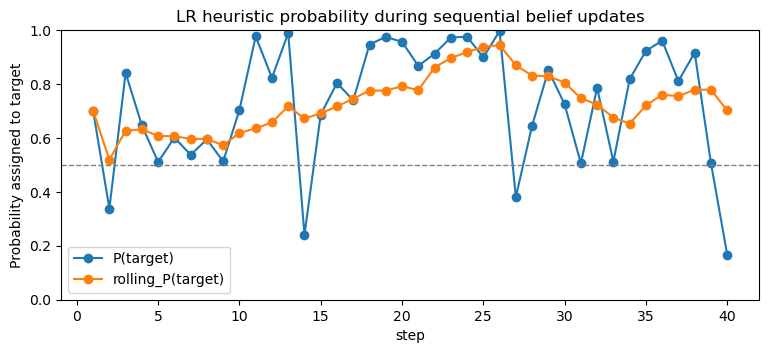

,step,instance_id,target,p1,P(target),time,rolling_P(target)
30,31,152,0,0.494,0.506,13.766,0.748
31,32,107,0,0.214,0.786,13.029,0.724
32,33,395,1,0.512,0.512,13.865,0.675
33,34,217,1,0.818,0.818,12.888,0.653
34,35,249,0,0.076,0.924,12.054,0.721
35,36,13,0,0.039,0.961,11.417,0.760
36,37,133,0,0.189,0.811,12.661,0.755
37,38,156,1,0.917,0.917,12.098,0.779
38,39,390,1,0.507,0.507,14.184,0.780
39,40,343,1,0.167,0.167,13.204,0.702


,feature,key,initial_mu,final_mu,final_variance
0,Alcohol,a0,1.0,1.8962,0.3834
1,Sulphates,a1,1.0,1.4237,0.4418
2,SO2,a2,-1.0,-1.1537,0.5503
3,Vinegar Taint,a3,-1.0,-1.3268,0.4724
4,pH,a4,-1.0,-0.5957,0.4175
5,Chlorides,a5,-1.0,-1.4516,0.6636


Episode mean P(target): 0.732


In [ ]:
episode_ids = rng.choice(np.asarray(bundle.instance_ids), size=40, replace=False).astype(int).tolist()
episode_norm, episode_y = bundle.loader.load_instances(episode_ids, normalize=True)
memory = prime_lr_heuristic_memory(bundle, params)
trace_rows = []
for step, (instance_id, x, y) in enumerate(zip(episode_ids, episode_norm, episode_y), start=1):
    y = int(y)
    probs, seconds, info = heuristic_prediction(x, y, memory=memory)
    trace_rows.append({'step': step, 'instance_id': instance_id, 'target': y,
                       'p1': probs[1], 'P(target)': probs[y], 'time': seconds})
    refresh_lr_heuristic_in_memory(memory, bundle.lr_exp, info, y)

trace_df = pd.DataFrame(trace_rows)
trace_df['rolling_P(target)'] = trace_df['P(target)'].rolling(8, min_periods=1).mean()
ax = trace_df.plot(x='step', y=['P(target)', 'rolling_P(target)'], ylim=(0, 1), figsize=(9, 3.5), marker='o')
ax.axhline(0.5, color='grey', linestyle='--', linewidth=1)
ax.set_ylabel('Probability assigned to target')
ax.set_title('LR heuristic probability during sequential belief updates')
plt.show()
display(trace_df.tail(10).round(3))

final_beliefs = []
for key, raw_coef in bundle.lr_exp.coefficients.items():
    chunk = memory.get_chunk(f"LR_coef_prob_{key.replace('=', '_')}")
    final_beliefs.append({'feature': feature_names.get(key, key), 'key': key,
                          'initial_mu': float(np.sign(raw_coef)),
                          'final_mu': chunk.slots['mu'], 'final_variance': chunk.slots['var']})
display(pd.DataFrame(final_beliefs).round(4))
print(f"Episode mean P(target): {trace_df['P(target)'].mean():.3f}")

## What to inspect next

- If the first sample table is weak before learning, the sign-only initial beliefs and decision scaling are strong suspects.
- If the learning curve remains flat, inspect `refresh_lr_heuristic_in_memory`: it updates only retrieved chunks and may not learn enough during an episode.
- If cases with `target = 0` or `target = 1` are disproportionately poor, group `trace_df` or `sample_df` by `target` to reveal directional bias.
- Use this notebook before changing the strategy implementation; it provides a compact regression check for any proposed fix.